In [10]:
# Importaciones generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Se carga el dataset 
# Resumen del Dataset: IBM HR Analytics Employee Attrition

### Este conjunto de datos Descubra los factores que provocan la deserción laboral y explore preguntas importantes como «muestre un desglose de la distancia desde el hogar según el puesto y la deserción» o «compare el ingreso mensual promedio según la educación y la deserción». Este es un conjunto de datos ficticio creado por científicos de datos de IBM.

### Resumen del Dataset: IBM HR Analytics Employee Attrition

| Variable | Tipo | Descripción | Valores / Ejemplo |
| :--- | :--- | :--- | :--- |
| **Age** | Numérica | 🎂 Edad del empleado en años. | 18 - 60 (Media: 36.9) |
| **Attrition** | Categórica | 🚪 Variable objetivo: ¿El empleado dejó la empresa? | No (84%), Yes (16%) |
| **Department** | Categórica | 🏢 Departamento al que pertenece el empleado. | Sales, Research & Development, Human Resources |
| **DistanceFromHome** | Numérica | 🚗 Distancia desde su casa al trabajo (en unidades genéricas). | 1 - 29 (Media: 9.2) |
| **EducationField** | Categórica | 🎓 Campo de estudio de la educación técnica/universitaria. | Life Sciences, Medical, Marketing, Technical Degree, ... |
| **JobRole** | Categórica | 💼 Rol específico que desempeña en la organización. | Sales Executive, Research Scientist, Laboratory Technician... |
| **MonthlyIncome** | Numérica | 💵 Ingreso mensual del empleado. | 1,009 - 19,999 (Media: 6,502) |
| **NumCompaniesWorked** | Numérica | 🏢 Número de empresas en las que ha trabajado previamente. | 0 - 9 (Media: 2.69) |
| **JobSatisfaction** | Ordinal | 😊 Nivel de satisfacción con el trabajo (Escala 1-4). | 1 (Bajo), 2 (Medio), 3 (Alto), 4 (Muy Alto) |
| **TotalWorkingYears** | Numérica | ⏱️ Total de años de experiencia laboral. | 0 - 40 (Media: 11.3) |
| **YearsAtCompany** | Numérica | 📅 Años de antigüedad en la empresa actual. | 0 - 40 (Media: 7.0) |
| **OverTime** | Categórica | ⏰ ¿El empleado trabaja horas extra? | Yes, No |


### Paso 1: Carga, Exploración y Limpieza de Datos

Cargamos los archivos del Dataset "city_lifestyle_dataset.csv" y realizamos la inspección inicial (nulos y duplicados).

In [11]:
df = pd.read_csv('./Employee-Attrition.csv') # Cargar dataset

fila = 'JobRole'
columna = 'EducationField'
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [15]:
# ==============================================================================
# PASO 1: TABLA DE CONTINGENCIAS (Réplica de Imagen 1)
# ==============================================================================
# Generamos la tabla cruzada con los márgenes (Totales)
tabla_contingencia = pd.crosstab(df[fila], df[columna], margins=True, margins_name="Total")

print(">>> PASO 1: Tabla de Contingencia (Frecuencias Absolutas)")
display(tabla_contingencia)

>>> PASO 1: Tabla de Contingencia (Frecuencias Absolutas)


EducationField,Human Resources,Life Sciences,Marketing,Medical,Other,Technical Degree,Total
JobRole,,,,,,,
Healthcare Representative,0,60,0,48,9,14,131
Human Resources,21,13,0,11,3,4,52
Laboratory Technician,0,119,0,99,22,19,259
Manager,6,40,14,32,5,5,102
Manufacturing Director,0,71,0,53,7,14,145
Research Director,0,36,0,35,4,5,80
Research Scientist,0,133,0,103,17,39,292
Sales Executive,0,107,122,65,13,19,326
Sales Representative,0,27,23,18,2,13,83


In [13]:
# ==============================================================================
# PASO 2: PERFILES FILA Y COLUMNA (Réplica de Imagen 2)
# ==============================================================================
# Para calcular perfiles, trabajamos sin los totales primero
N = pd.crosstab(df[fila], df[columna]) 

# --- A) Perfiles Fila (Row Profiles) ---
# Fórmula: Cada celda dividida por el total de su FILA
# Interpretación: "De todos los que son 'Sales Executive', ¿qué % estudió Marketing?"
perfiles_fila = N.div(N.sum(axis=1), axis=0) * 100

print("\n>>> PASO 2A: Perfiles Fila (Probabilidad Condicional dado el ROL)")
# Mostramos con formato de porcentaje para facilitar lectura
display(perfiles_fila.round(2).style.background_gradient(cmap='Blues', axis=1))

# --- B) Perfiles Columna (Column Profiles) ---
# Fórmula: Cada celda dividida por el total de su COLUMNA
# Interpretación: "De todos los que estudiaron 'Medical', ¿qué % trabaja como Manager?"
perfiles_columna = N.div(N.sum(axis=0), axis=1) * 100

print("\n>>> PASO 2B: Perfiles Columna (Probabilidad Condicional dada la EDUCACIÓN)")
display(perfiles_columna.round(2).style.background_gradient(cmap='Reds', axis=0))


>>> PASO 2A: Perfiles Fila (Probabilidad Condicional dado el ROL)


EducationField,Human Resources,Life Sciences,Marketing,Medical,Other,Technical Degree
JobRole,,,,,,
Healthcare Representative,0.000000,45.800000,0.000000,36.640000,6.870000,10.690000
Human Resources,40.380000,25.000000,0.000000,21.150000,5.770000,7.690000
Laboratory Technician,0.000000,45.950000,0.000000,38.220000,8.490000,7.340000
Manager,5.880000,39.220000,13.730000,31.370000,4.900000,4.900000
Manufacturing Director,0.000000,48.970000,0.000000,36.550000,4.830000,9.660000
Research Director,0.000000,45.000000,0.000000,43.750000,5.000000,6.250000
Research Scientist,0.000000,45.550000,0.000000,35.270000,5.820000,13.360000
Sales Executive,0.000000,32.820000,37.420000,19.940000,3.990000,5.830000
Sales Representative,0.000000,32.530000,27.710000,21.690000,2.410000,15.660000



>>> PASO 2B: Perfiles Columna (Probabilidad Condicional dada la EDUCACIÓN)


EducationField,Human Resources,Life Sciences,Marketing,Medical,Other,Technical Degree
JobRole,,,,,,
Healthcare Representative,0.000000,9.900000,0.000000,10.340000,10.980000,10.610000
Human Resources,77.780000,2.150000,0.000000,2.370000,3.660000,3.030000
Laboratory Technician,0.000000,19.640000,0.000000,21.340000,26.830000,14.390000
Manager,22.220000,6.600000,8.810000,6.900000,6.100000,3.790000
Manufacturing Director,0.000000,11.720000,0.000000,11.420000,8.540000,10.610000
Research Director,0.000000,5.940000,0.000000,7.540000,4.880000,3.790000
Research Scientist,0.000000,21.950000,0.000000,22.200000,20.730000,29.550000
Sales Executive,0.000000,17.660000,76.730000,14.010000,15.850000,14.390000
Sales Representative,0.000000,4.460000,14.470000,3.880000,2.440000,9.850000


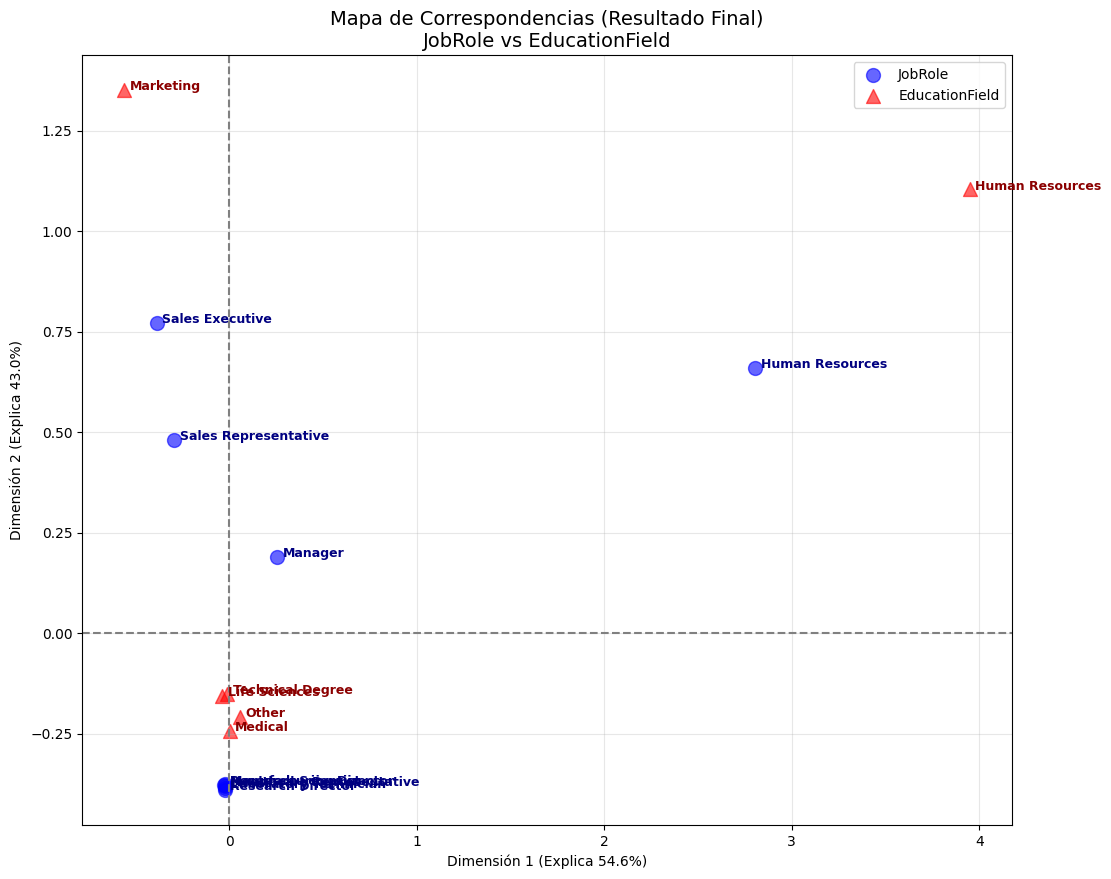

In [14]:
# ==============================================================================
# PASO 3: DISTANCIA CHI-CUADRADO Y MAPA (El Resultado del Análisis)
# ==============================================================================
# Una vez que tenemos los perfiles (Paso 2), el Análisis de Correspondencias 
# calcula la distancia entre ellos para graficarlos.

# Implementación robusta SVD (Sin necesidad de librería 'prince')
X = pd.crosstab(df[fila], df[columna])
P = X / X.sum().sum()
r = P.sum(axis=1)
c = P.sum(axis=0)
E = np.outer(r, c)
R = (P - E) / np.sqrt(E)

# Descomposición
U, s, Vt = np.linalg.svd(R, full_matrices=False)

# Coordenadas
row_coords = np.diag(1/np.sqrt(r)) @ U[:, :2] @ np.diag(s[:2])
col_coords = np.diag(1/np.sqrt(c)) @ Vt[:2].T @ np.diag(s[:2])

# Graficamos
plt.figure(figsize=(12, 10))
plt.title(f'Mapa de Correspondencias (Resultado Final)\n{fila} vs {columna}', fontsize=14)

# Puntos Fila (Azul)
plt.scatter(row_coords[:, 0], row_coords[:, 1], c='blue', s=100, alpha=0.6, label=fila)
for i, txt in enumerate(X.index):
    plt.text(row_coords[i, 0]+0.03, row_coords[i, 1], txt, color='navy', fontsize=9, weight='bold')

# Puntos Columna (Rojo)
plt.scatter(col_coords[:, 0], col_coords[:, 1], c='red', marker='^', s=100, alpha=0.6, label=columna)
for i, txt in enumerate(X.columns):
    plt.text(col_coords[i, 0]+0.03, col_coords[i, 1], txt, color='darkred', fontsize=9, weight='bold')

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel(f"Dimensión 1 (Explica {round((s[0]**2/sum(s**2))*100,1)}%)")
plt.ylabel(f"Dimensión 2 (Explica {round((s[1]**2/sum(s**2))*100,1)}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()